<script type="text/x-mathjax-config">
  MathJax.Hub.Config({
    tex2jax: {
      inlineMath: [['$','$'], ['\\(','\\)']],
      displayMath: [['$$','$$'], ['\\[','\\]']]
    },
    TeX: {
      extensions: ["color.js"]
    },
    "HTML-CSS": {
      availableFonts: ["TeX"],
      linebreaks: { automatic: true }
    }
  });
</script>

<script src="https://cdn.jsdelivr.net/npm/mathjax@2/MathJax.js?config=TeX-AMS-MML_HTMLorMML" type="text/javascript"></script>

<!-- libreria per paginazione -->
<script src="https://unpkg.com/pagedjs/dist/paged.polyfill.js"></script>

<style>
@media all {
  body {
    font-weight: 700;
  }
  /* Rende le formule MathJax più spesse */
  .MathJax, .MathJax_Display {
    font-weight: bold;
  }
  .bold-text {
    font-weight: bold;
  }
  .heavy-text {
    font-weight: 700;
  }
}


/* Solo per la stampa/PDF */
@media print {
  @page {
    size: auto;
    margin: 7mm 0mm 10mm 0mm; /* margini come prima, solo un po' più basso */
  }

  /* Solo footer con numeri, nessun header */
  @page {
    @top-center {
      content: none;
    }
    @bottom-center {
      content: counter(page) " / " counter(pages);
      font-size: 9pt;
      font-weight: normal;
      color: #333;
    }
  }
}
</style>


# K Nearest Neighbour (KNN)

We are going to apply KNN algorithm on some simple datasets

*   Toy dataset
*   IRIS: the dataset of flowers
*   Breast cancer dataset (class assignment)
*   California housing data (homework)



# Toy dataset

In [1]:
# we import a library where KNN is already implemented. it also supports nice visualization on toy datasets

#python 3
# cpu

#!pip install mglearn # anything with an exclamation mark means first install the package

import mglearn
import matplotlib.pyplot as plt # a library for plotting

X.shape: (26, 2)


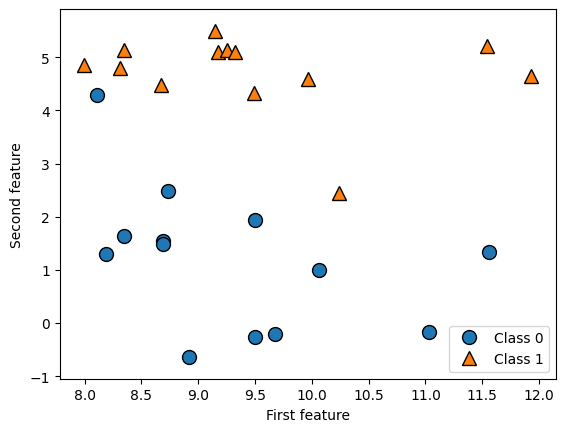

In [2]:
# lets visualize some fake data

X, y = mglearn.datasets.make_forge() # this is a function that creates a fixed toy dataset for classification.
# plot dataset
mglearn.discrete_scatter(X[:, 0], X[:, 1], y) # creates a scatter plot where the points are colored according to their class label (y).
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print("X.shape:", X.shape)

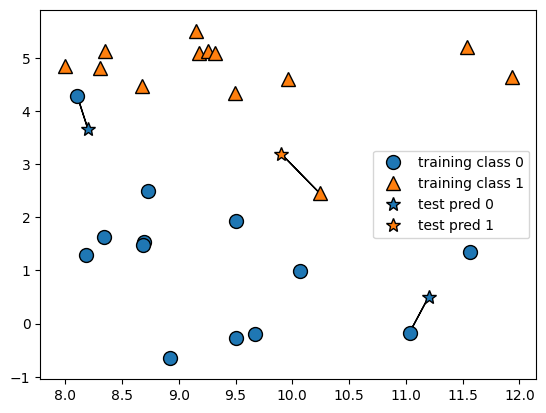

In [3]:
# lets explore the mglearn library on a toy dataset. FUnzione deterministica, non randomica, che genera un dataset di classificazione con 2 classi e 2 caratteristiche. Il dataset è progettato per essere facilmente visualizzabile e comprende punti appartenenti a due classi distinte.

mglearn.plots.plot_knn_classification(n_neighbors=1) # creates a plot that shows the decision boundaries of a KNN classifier with 1 neighbor on a toy dataset.

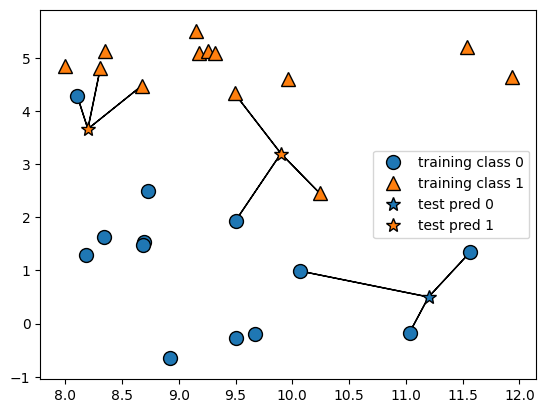

In [4]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

# IRIS dataset

In [5]:
# import libraries and load the IRIS dataset already provided by the sklearn library

from sklearn.datasets import load_iris
import numpy as np
iris_dataset = load_iris()

In [6]:
# visualize what the dataset object contains

print("Keys of iris_dataset\n", iris_dataset.keys())

Keys of iris_dataset
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [7]:
# check the class labels

np.unique(iris_dataset['target'], return_counts=True)

(array([0, 1, 2]), array([50, 50, 50]))

In [8]:
# count the number of samples in the dataset

print(len(iris_dataset['data']))

150


In [9]:
# lets split the dataset into train and validation sets
# we are going to use a helper function

from sklearn.model_selection import train_test_split

# 120/150 = 80% of the data for training, the rest for validation
X_train, X_val, y_train, y_val = train_test_split(iris_dataset['data'], iris_dataset['target'], train_size=120)
print(X_train.shape)
print(y_train.shape)

(120, 4)
(120,)


In [10]:
# to better visualize the dataset in the form of a table we are going to use a library called pandas

import pandas as pd

In [11]:
# visualize the features
df = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.5,3.0,5.8,2.2
1,4.9,2.4,3.3,1.0
2,6.3,2.7,4.9,1.8
3,7.1,3.0,5.9,2.1
4,6.7,3.3,5.7,2.5


array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

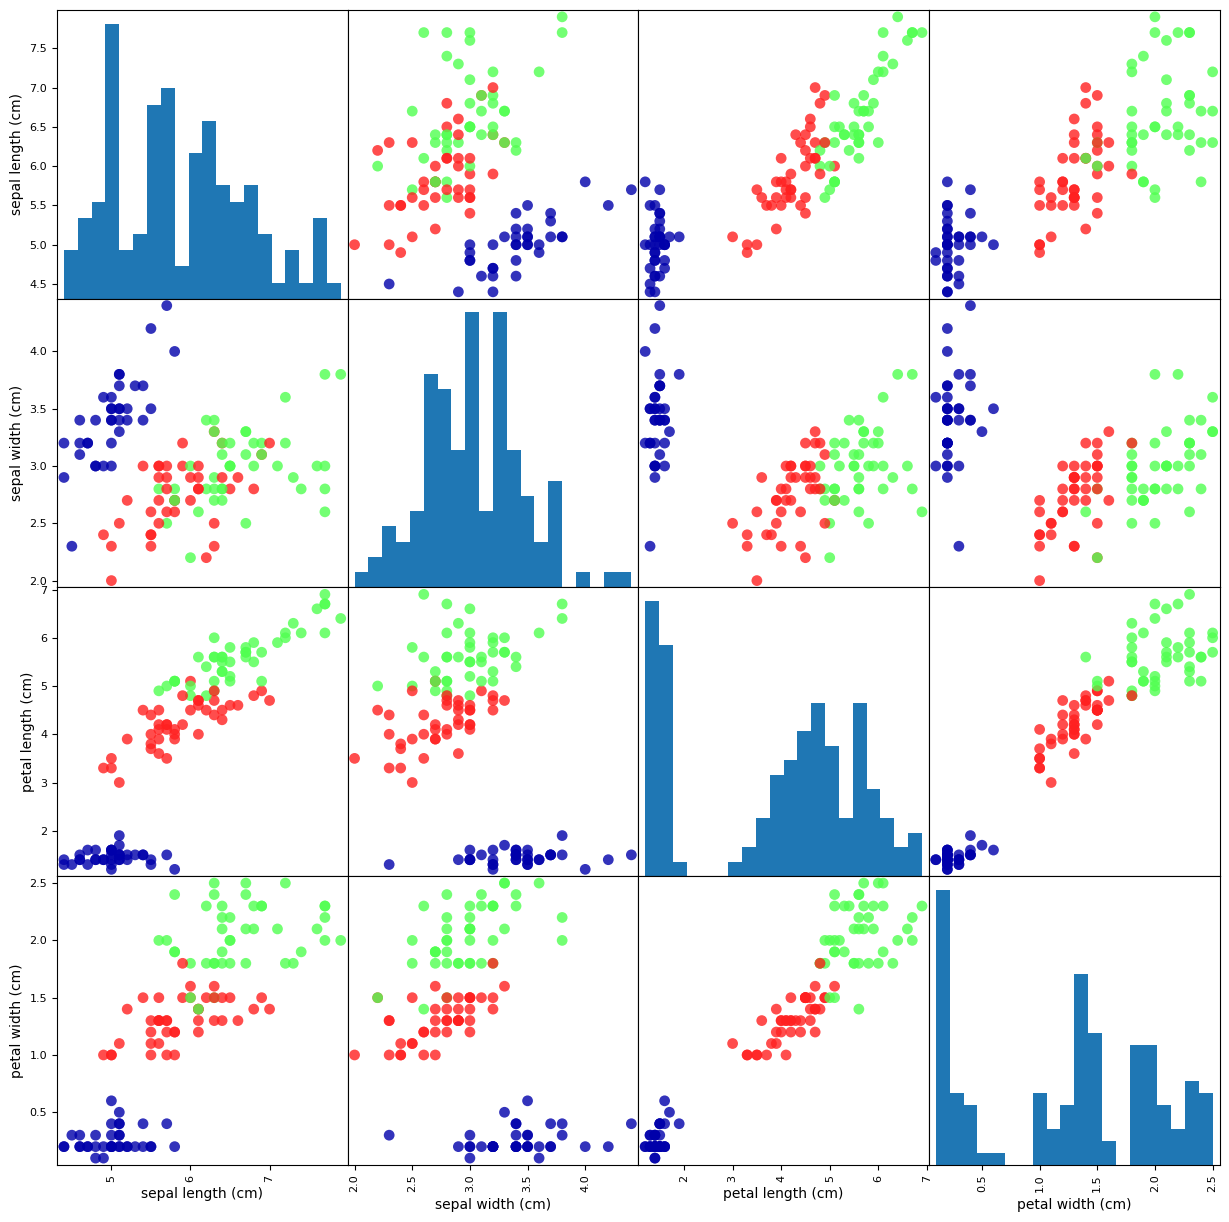

In [12]:
# we can visualize the dataset

pd.plotting.scatter_matrix(df, c=y_train, figsize=(15, 15),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8, cmap=mglearn.cm3)

In [13]:
# we will use the already implemented KNN algorithm in sklearn on IRIS dataset

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

In [14]:
# now we give the IRIS data to the KNN algorithm to "learn" the model. This in sklearn dictionary is called "fitting the data"

knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
# calculate the accuracy on the validation set. This is done using the "score" function

knn.score(X_val, y_val)

0.9666666666666667

In [16]:
# if you want to make individual predictions then we use "predict" function

knn.predict(X_val[0].reshape(1, 4)) # predict the class label for the first sample in the validation set. We need to reshape it to make it a 2D array with 1 row and 4 columns, which is the expected input shape for the predict function. The output will be an array containing the predicted class label for that sample.

array([2])

In [17]:
# recap: what is reshape? It is used to change the shape of an array or matrix in general

temp = np.array([3.2, 2.1, 3.1, 4.5]) # shape: 1 x 4
temp.reshape(2, 2) # lets turn the 1D array into a 2 x 2 matrix. 
''' The second row is filled with the remaining elements of the array. 
The total number of elements must remain the same, so we cannot reshape it into a 3 x 3 matrix because that would require 9 elements, 
but we only have 4. We can reshape it into a 2 x 2 matrix because that requires 4 elements, 
which is exactly what we have. The resulting matrix will look like this:'''


' The second row is filled with the remaining elements of the array. \nThe total number of elements must remain the same, so we cannot reshape it into a 3 x 3 matrix because that would require 9 elements, \nbut we only have 4. We can reshape it into a 2 x 2 matrix because that requires 4 elements, \nwhich is exactly what we have. The resulting matrix will look like this:'

In [18]:
# prediction on the full validation set

knn.predict(X_val)

array([2, 0, 0, 1, 0, 2, 1, 2, 1, 0, 1, 1, 1, 0, 2, 0, 0, 1, 2, 0, 1, 1,
       0, 0, 0, 1, 2, 0, 0, 0])

In [19]:
# let's try different values of K in the KNN and print the accuracy for each K

for n_neighbour in range(1,10):
    clf = KNeighborsClassifier(n_neighbors=n_neighbour).fit(X_train,y_train)
    print(f'n={n_neighbour}, score={clf.score(X_val,y_val)}')

n=1, score=0.9666666666666667
n=2, score=0.9666666666666667
n=3, score=0.9666666666666667
n=4, score=0.9666666666666667
n=5, score=0.9333333333333333
n=6, score=0.9333333333333333
n=7, score=0.9333333333333333
n=8, score=0.9
n=9, score=0.9333333333333333


In [20]:
# let do feature scaling

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [21]:
# 1. standard scaler (Z-score normalization)

std_scaler = StandardScaler()

# fit on the training data and transform both train and validation sets
X_train_std = std_scaler.fit_transform(X_train)
X_val_std = std_scaler.transform(X_val)

In [22]:
# lets visualize the standardized dataset using pandas

df_std = pd.DataFrame(X_train_std, columns=iris_dataset.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.5,3.0,5.8,2.2
1,4.9,2.4,3.3,1.0
2,6.3,2.7,4.9,1.8
3,7.1,3.0,5.9,2.1
4,6.7,3.3,5.7,2.5


In [23]:
df_std.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.742169,-0.077627,1.085639,1.247543
1,-1.196558,-1.474908,-0.337839,-0.345065
2,0.499828,-0.776267,0.573187,0.716674
3,1.469191,-0.077627,1.142578,1.114826
4,0.984510,0.621014,1.028700,1.645696


In [24]:
# lets verify if the mean and std of each feature (or column) is zero and 1, respectively
# What we expect to see:
# mean = 0, std = 1

print(f"\nMean of first feature: {df_std.iloc[:, 0].mean():.2f}")
print(f"Std Dev of first feature: {df_std.iloc[:, 0].std():.2f}")


Mean of first feature: 0.00
Std Dev of first feature: 1.00


In [25]:
# 2. Min max scaler

minmax_scaler = MinMaxScaler()

# fit on the training data and transform both train and validation sets
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_val_minmax = minmax_scaler.transform(X_val)

# visualize the data
df_minmax = pd.DataFrame(X_train_minmax, columns=iris_dataset.feature_names)
df_minmax.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.600000,0.416667,0.807018,0.875000
1,0.142857,0.166667,0.368421,0.375000
2,0.542857,0.291667,0.649123,0.708333
3,0.771429,0.416667,0.824561,0.833333
4,0.657143,0.541667,0.789474,1.000000


In [26]:
# print the statistics
# what we expect to see:
# mean = 0, max = 1
print(f"\nMean of first feature: {df_minmax.iloc[:, 0].min():.2f}")
print(f"Std Dev of first feature: {df_minmax.iloc[:, 0].max():.2f}")


Mean of first feature: 0.00
Std Dev of first feature: 1.00


In [27]:
# lets use standardized features to train the KNN model

knn = KNeighborsClassifier(n_neighbors=2)
clf = knn.fit(X_train_std, y_train)
print(f"Score with standardized features: {clf.score(X_val_std, y_val)}")

Score with standardized features: 0.9333333333333333


# Breast cancer dataset (class assignment)

The task is the following:
1. Load the dataset using sklearn function (already done)
2. Visualize data using pandas
3. Split the dataset into train/val sets
3. Train KNN algorithm with different values of K
4. Apply feature scaling and see if it improves performance
5. Bonus: plot the train/val accuracy with different values of K to understand overfitting and underfitting (boilerplate code provided)

In [28]:
# load the dataset

from sklearn.datasets import load_breast_cancer
bc_dataset = load_breast_cancer()

In [29]:
print("Keys in the dataset:", bc_dataset.keys())

Keys in the dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [30]:
# finish the remaining parts

In [31]:
# code snippet to plot the train/val accuracy with different values of K

# assume that we have stored the train and val accuracy in two lists

train_acc = [] # create an empty list for the train accuracy
train_acc.append(2)
train_acc.append(2.3)
print(train_acc)

# similarly we will have a val_acc list
val_acc = []


[2, 2.3]


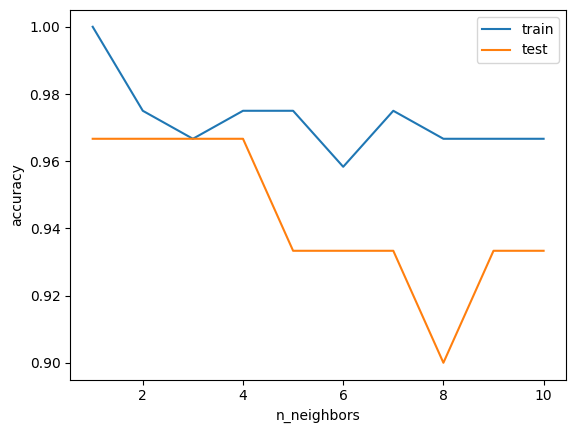

In [32]:
neigbours_settings = range (1,11) # we want to try K from 1 to 10

# plot the accuracies

train_acc = []
val_acc = []
for n_neighbour in neigbours_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbour)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    val_acc.append(clf.score(X_val, y_val))

plt.plot(neigbours_settings, train_acc, label='train')
plt.plot(neigbours_settings, val_acc, label='test')

plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.legend()

# California Housing dataset (homework)

This is a more real-world dataset containing information about houses and prices. So this is a regression task. We want to adapt this to the classification task.

Initial code to do that has been implemented for you.

In [33]:
from sklearn.datasets import fetch_california_housing

# as_frame=True loads the data in a dataframe format, with other metadata besides it
california_housing = fetch_california_housing(as_frame=True)
# Select only the dataframe part and assign it to the df variable
df = california_housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
# we are converting the real values into categorical values
# qcut divides the data into (4 in this case) equal-sized bins based on the quantiles of the data.
# and assigning labels 1, 2, 3, and 4 to each bin. 
# The resulting "MedHouseValCat" column will contain the categorical values corresponding to the quartiles of the original "MedHouseVal" values. 
df["MedHouseValCat"] = pd.qcut(df["MedHouseVal"], 4, retbins=False, labels=[1, 2, 3, 4])

y = df['MedHouseValCat'] # the new target (or class labels) for the entire dataset
X = df.drop(['MedHouseVal', 'MedHouseValCat'], axis = 1) # the features of the entire dataset

In [35]:
df.head() # just for visualization. You need to use x and y in the above column to train the KNN algorithm

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,MedHouseValCat
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,4
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,4
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,4
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,4


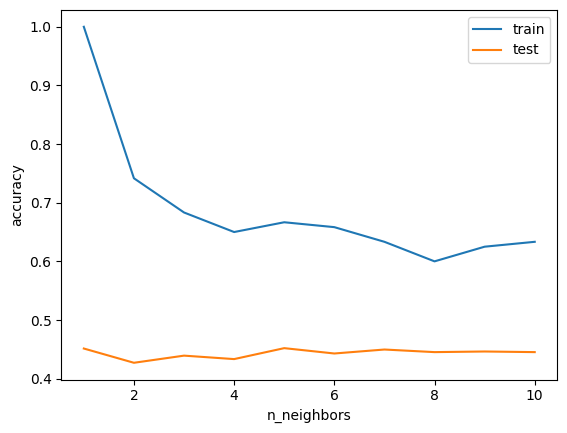

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 120/150 = 80% of the data for training, the rest for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=120)
# standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
# KNN model with different values of K
neigbours_settings = range (1,11) # we want to try K from 1 to 10
train_acc = []
val_acc = []
for n_neighbour in neigbours_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbour)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    val_acc.append(clf.score(X_val_scaled, y_val))
# plot the accuracies
plt.plot(neigbours_settings, train_acc, label='train')
plt.plot(neigbours_settings, val_acc, label='test')
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.legend()
plt.show()

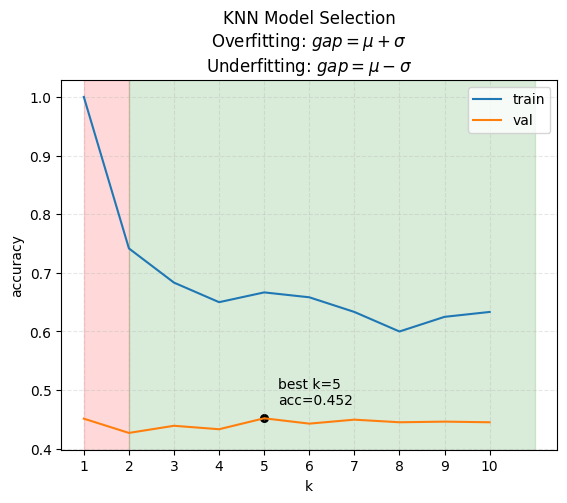

In [38]:
import numpy as np
import matplotlib.pyplot as plt

k_values = list(neigbours_settings)

# GAP
gap = np.array(train_acc) - np.array(val_acc)

# data-driven thresholds
mu = np.mean(gap)
sigma = np.std(gap)

labels = []
for g in gap:
    if g > mu + sigma:
        labels.append("overfit")
    elif g < mu - sigma:
        labels.append("underfit")
    else:
        labels.append("good")

# function to extract the spans of k values for each label
def extract_spans(k_vals, labels, target):
    spans = []
    start = None
    for i, lab in enumerate(labels):
        if lab == target and start is None:
            start = k_vals[i]
        elif lab != target and start is not None:
            spans.append((start, k_vals[i]))
            start = None
    if start is not None:
        spans.append((start, k_vals[-1] + 1))
    return spans

overfit_spans = extract_spans(k_values, labels, "overfit")
good_spans = extract_spans(k_values, labels, "good")
underfit_spans = extract_spans(k_values, labels, "underfit")

# BEST k
best_idx = np.argmax(val_acc)
best_k = k_values[best_idx]

# PLOT
plt.plot(k_values, train_acc, label="train")
plt.plot(k_values, val_acc, label="val")

# axvspan from spans values
for a, b in overfit_spans:
    plt.axvspan(a, b, color='red', alpha=0.15)

for a, b in good_spans:
    plt.axvspan(a, b, color='green', alpha=0.15)

for a, b in underfit_spans:
    plt.axvspan(a, b, color='blue', alpha=0.10)

# best k
plt.scatter(best_k, val_acc[best_idx], color='black', s=30)
plt.annotate(
    f"best k={best_k}\nacc={val_acc[best_idx]:.3f}",
    (best_k, val_acc[best_idx]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.xticks(k_values)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.title(
    "KNN Model Selection\n"
    r"Overfitting: $gap = \mu + \sigma$"  "\n"  "Underfitting: $gap = \mu - \sigma$",
    fontsize=12
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()